# 🚗 Retraining with Real Driving Data

This notebook guides you through the process of taking your **real-world driving data** (collected via the Android app), labeling it automatically based on physics, and fine-tuning the ML model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import glob
import os
import tensorflow as tf

# Settings
DATA_DIR = '../data/'
REAL_DATA_PATTERN = DATA_DIR + "*.csv"  # Looks for any CSV in data/
MODEL_DIR = '../android/DriverWarningApp/app/src/main/assets/'

## 1. Load Real Data
We load all CSV files found in the data directory that aren't the training set.

In [2]:
all_files = glob.glob(REAL_DATA_PATTERN)
real_dfs = []

print("Found files:", all_files)

for filename in all_files:
    if "large_training_data" in filename or "sim_trips" in filename:
        continue # Skip synthetic data for now
        
    try:
        df = pd.read_csv(filename)
        # Check if it has required columns
        if 'acc_x' in df.columns:
            real_dfs.append(df)
            print(f"✅ Loaded {filename} ({len(df)} samples)")
    except Exception as e:
        print(f"❌ Error loading {filename}: {e}")

if not real_dfs:
    print("⚠️ No real driving data found! Please copy your CSV file to c:/Users/akhia/driver_safety/data/")
    # Fallback to empty DF to prevent crash
    full_real_df = pd.DataFrame()
else:
    full_real_df = pd.concat(real_dfs, ignore_index=True)
    print(f"\nTotal Real Samples: {len(full_real_df)}")

Found files: ['../data\\drive_session_20251211_181516.csv', '../data\\large_training_data.csv', '../data\\sim_trips.csv']
✅ Loaded ../data\drive_session_20251211_181516.csv (135 samples)

Total Real Samples: 135


## 2. Auto-Labeling based on Physics
The app records raw collected data. We need to tell the model what was "Safe" and what was "Dangerous".
We use **Lateral Acceleration** (G-force) as the ground truth.

- **Safe (0):** < 1.5 m/s²
- **Mild (1):** 1.5 - 3.5 m/s²
- **Urgent (2):** 3.5 - 5.5 m/s²
- **Hectic (3):** > 5.5 m/s²

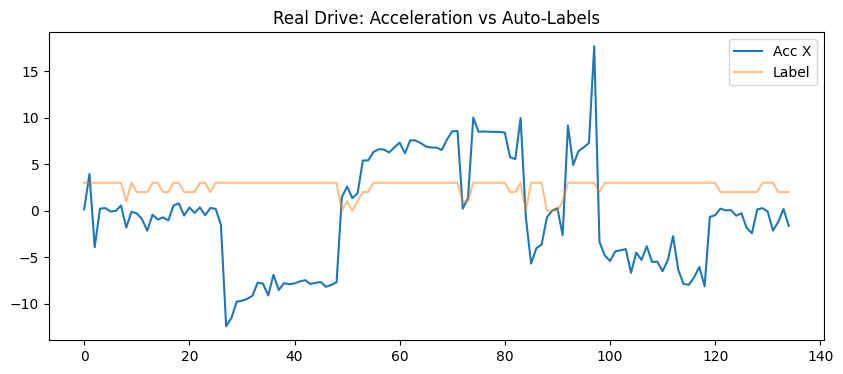

label
3    98
2    25
1     6
0     6
Name: count, dtype: int64


In [3]:
def auto_label(row):
    # Calculate magnitude of lateral forces (assuming phone flat-ish)
    # Note: Adjust axes if phone was vertical. Usually X/Y capture turns.
    lat_accel = np.sqrt(row['acc_x']**2 + row['acc_y']**2)
    
    if lat_accel < 2.0: return 0 # Safe
    if lat_accel < 4.0: return 1 # Mild
    if lat_accel < 6.0: return 2 # Urgent
    return 3 # Hectic

if not full_real_df.empty:
    full_real_df['label'] = full_real_df.apply(auto_label, axis=1)
    
    # Visualize
    plt.figure(figsize=(10,4))
    plt.plot(full_real_df['acc_x'], label='Acc X')
    plt.plot(full_real_df['label'], label='Label', alpha=0.5)
    plt.legend()
    plt.title("Real Drive: Acceleration vs Auto-Labels")
    plt.show()
    
    print(full_real_df['label'].value_counts())

## 3. Mix with Synthetic Data
To prevent "catastrophic forgetting" (where the model learns your specific car but forgets general physics), we mix real data with the original synthetic data.

In [4]:
try:
    synthetic_df = pd.read_csv(DATA_DIR + "large_training_data.csv")
    print(f"Loaded {len(synthetic_df)} synthetic samples")
except:
    print("⚠️ Large training data not found, generating small batch...")
    synthetic_df = pd.DataFrame(np.random.randn(1000, 7), columns=['speed','acc_x','acc_y','acc_z','gyro_x','gyro_y','gyro_z'])
    synthetic_df['label'] = 0

# Combine
if not full_real_df.empty:
    # Weighted mix: Replicate real data to match synthetic size importance if needed
    # For now, just 1:1 concatenation
    features = ['speed', 'acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']
    
    X_real = full_real_df[features].values
    y_real = full_real_df['label'].values
    
    X_synth = synthetic_df[features].values
    y_synth = synthetic_df['label'].values
    
    X = np.concatenate([X_synth, X_real])
    y = np.concatenate([y_synth, y_real])
else:
    X = synthetic_df[['speed','acc_x','acc_y','acc_z','gyro_x','gyro_y','gyro_z']].values
    y = synthetic_df['label'].values

print(f"Training set size: {len(X)}")

Loaded 76057 synthetic samples


KeyError: 'label'

## 4. Train & Export
We retrain the model and save it directly to the Android app assets.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Preprocess
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_cat = to_categorical(y, num_classes=4)

X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_cat, test_size=0.2)

# Model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(7,)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(4, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_val, y_val), batch_size=32)

# Save Scaler
with open(MODEL_DIR + 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✅ Scaler saved to app assets")

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open(MODEL_DIR + 'curve_detector.tflite', 'wb') as f:
    f.write(tflite_model)
print("✅ TFLite model saved to app assets")